In [ ]:
!pip install pennylane pennylane-qiskit torch torchvision

INFO: pip is looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.1/797.1 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 49.1 MB/s eta 0:

In [2]:
pip install -U pennylane==0.41.1 pennylane-lightning==0.41.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 2.3 MB/s eta 0:00:00
  Attempting uninstall: pennylane-lightning
    Found existing installation: pennylane_lightning 0.42.0
    Uninstalling pennylane_lightning-0.42.0:
      Successfully uninstalled pennylane_lightning-0.42.0
  Attempting uninstall: pennylane
    Found existing installation: pennylane 0.42.0
    Uninstalling pennylane-0.42.0:
      Successfully uninstalled pennylane-0.42.0


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import pennylane as qml
from pennylane import numpy as np

/usr/local/lib/python3.11/dist-packages/pennylane/capture/capture_operators.py:33: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.4.28. You have version 0.5.2 installed. Please downgrade JAX to <=0.4.28 to avoid runtime errors.
  warnings.warn(


In [11]:
# 1. Pick the device at the top of your script
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# MNIST data - downscaled......since quantum generators can only handle samll output

transform = transforms.Compose([
    transforms.Resize((8,8)),         # Downscale 28x28 → 4x4
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

# load the full dataset
dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# LIMIT dataset to first 500 samples
dataset = torch.utils.data.Subset(dataset, range(1000))

# dataloader
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

In [5]:
# defining quantum circuit

n_qubits = 8
#dev = qml.device("default.qubit", wires=n_qubits)
dev = qml.device("lightning.qubit", wires=n_qubits)

@qml.qnode(dev, interface="torch", diff_method="parameter-shift", cache = True)
def quantum_circuit(inputs, weights):

    # Angle encoding
    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)

    # Variational layers
    qml.templates.StronglyEntanglingLayers(weights, wires=range(n_qubits))

    # Measurement
    return tuple(qml.expval(qml.PauliZ(i)) for i in range(n_qubits))


In [6]:
# defining quantum generator

class QuantumGenerator(nn.Module):
    def __init__(self):
        super().__init__()

        # Hardcoded config
        self.latent_dim = 32
        self.n_qubits = 8
        self.n_layers = 8

        # Latent → qubit input
        self.latent_to_qubit = nn.Linear(self.latent_dim, self.n_qubits)

        # Quantum weights for StronglyEntanglingLayers
        self.weights = nn.Parameter(0.01 * torch.randn(self.n_layers, self.n_qubits, 3))

        # Output postprocessing to image shape (16 pixels)
        self.postprocess = nn.Linear(self.n_qubits, 64)

    def forward(self, z):
        outputs = []
        for i in range(z.shape[0]):

            # Map latent vector to qubit inputs
            input_qubit = self.latent_to_qubit(z[i])

            out = quantum_circuit(input_qubit, self.weights)  # tuple of floats

            out_tensor = torch.stack(list(out))  # tensor of shape [n_qubits]

            # Apply quantum circuit (no torch.tensor conversion!)
            #out_tensor = quantum_circuit(input_qubit, self.weights)

            outputs.append(out_tensor)

        # Stack batch of outputs
        q_out = torch.stack(outputs)  # shape: [batch_size, n_qubits]

        # Postprocess to 16-pixel image
        return self.postprocess(q_out)  # shape: [batch_size, 16]

In [7]:
# classical discriminator

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            #nn.Linear(4, 64),
            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )


        '''
        self.model = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=1, padding=1),  # 4x4 → 4x4
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(32 * 4 * 4, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        '''
        '''
        self.model = nn.Sequential(
            nn.Linear(16, 32),  # 24 instead of 16
            nn.LeakyReLU(0.2),
            #nn.Linear(64, 32),
            #nn.LeakyReLU(0.2),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
        '''
    def forward(self, img):
        flat = img.view(img.size(0), -1)
        return self.model(flat)

In [8]:
# models and optimisers

G = QuantumGenerator()
D = Discriminator()

# Weight initialization
def weights_init(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

G.apply(weights_init)
D.apply(weights_init)

# Use the correct loss (no Sigmoid in D)
criterion = nn.BCEWithLogitsLoss()

optimizer_G = optim.Adam(G.parameters(), lr=0.005)
optimizer_D = optim.Adam(D.parameters(), lr=0.0005)

In [27]:
z = torch.randn(1, 16).to(device)

import time
start = time.time()
G_loss.backward()
end = time.time()
print("forward time", end - start)

NameError: name 'G_loss' is not defined

In [9]:
import time
G_losses = []
D_losses = []


In [ ]:
# training

# BEFORE LOOP
G = G.to(device)
D = D.to(device)

epochs = 10

for epoch in range(epochs):
    for i, (real_imgs, _) in enumerate(dataloader):

        batch_size = real_imgs.size(0)
        real_imgs = real_imgs.to(device)
        #real_imgs = real_imgs.view(batch_size, -1).to(device)

        #real_labels = torch.ones(batch_size, 1)
        #fake_labels = torch.zeros(batch_size, 1)
        #real_labels = torch.full((batch_size, 1), 0.9)
        #fake_labels = torch.full((batch_size, 1), 0.1)
        real_labels = torch.empty(batch_size, 1).uniform_(0.7, 1.0).to(device)
        fake_labels = torch.empty(batch_size, 1).uniform_(0.0, 0.3).to(device)

        # Train Discriminator
        if i%4 == 0:


          # Train Discriminator

          z_d = torch.randn(batch_size, 32).to(device)
          gen_out_d = G(z_d).detach()  # detach so D doesn't store gradients


          fake_imgs_d = gen_out_d.view(batch_size, 1, 8, 8)

          # Optional input noise for regularization:

          #fake_imgs = fake_imgs + 0.05 * torch.randn_like(fake_imgs)

          #real_imgs = real_imgs + 0.05 * torch.randn_like(real_imgs)

          fake_imgs_d = fake_imgs_d + 0.05 * torch.randn_like(fake_imgs_d)

          real_imgs_noisy = real_imgs + 0.05 * torch.randn_like(real_imgs)


          D_real = D(real_imgs_noisy)
          D_fake = D(fake_imgs_d)

          D_loss_real = criterion(D_real, real_labels)
          D_loss_fake = criterion(D_fake, fake_labels)
          D_loss = D_loss_real + D_loss_fake

          optimizer_D.zero_grad()
          D_loss.backward()
          optimizer_D.step()
          D_losses.append(D_loss.item())
        else:
          D_losses.append(None)  # dummy value for logging



        # Train Generator

        z_g = torch.randn(batch_size, 32).to(device)

        start = time.time()
        gen_out_g = G(z_g)
        print("Generator forward time:", time.time() - start)
        print(f"Epoch {epoch+1}, Batch {i+1}/{len(dataloader)}")
        
        fake_imgs_g = gen_out_g.view(batch_size, 1, 8, 8)
        D_fake_g = D(fake_imgs_g)

        G_loss = criterion(D_fake_g, real_labels)

        optimizer_G.zero_grad()
        G_loss.backward()
        optimizer_G.step()
        # save losses

        G_losses.append(G_loss.item())

    print(f"Epoch [{epoch+1}/{epochs}] D Loss: {D_loss.item():.4f} G Loss: {G_loss.item():.4f}")


Streaming output truncated to the last 5000 lines.
Generator forward time: 0.04778623580932617
Epoch 1, Batch 6/250
Generator forward time: 0.05387258529663086
Epoch 1, Batch 7/250
Generator forward time: 0.04943704605102539
Epoch 1, Batch 8/250
Generator forward time: 0.050421953201293945
Epoch 1, Batch 9/250
Generator forward time: 0.05613231658935547
Epoch 1, Batch 10/250
Generator forward time: 0.05011343955993652
Epoch 1, Batch 11/250
Generator forward time: 0.0505063533782959
Epoch 1, Batch 12/250
Generator forward time: 0.05216503143310547
Epoch 1, Batch 13/250
Generator forward time: 0.06959795951843262
Epoch 1, Batch 14/250
Generator forward time: 0.05359482765197754
Epoch 1, Batch 15/250
Generator forward time: 0.05288386344909668
Epoch 1, Batch 16/250
Generator forward time: 0.08914542198181152
Epoch 1, Batch 17/250
Generator forward time: 0.07144641876220703
Epoch 1, Batch 18/250
Generator forward time: 0.08218884468078613
Epoch 1, Batch 19/250
Generator forward time: 0.047

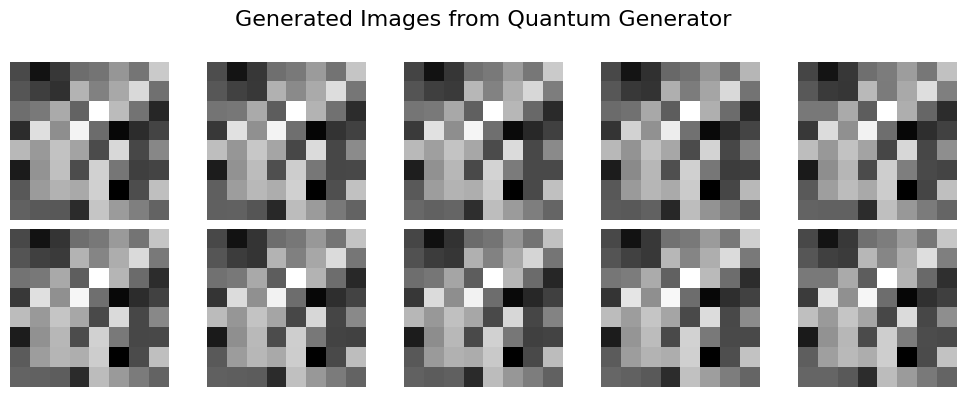

In [27]:
import matplotlib.pyplot as plt
import torch

# Set number of samples to generate
num_samples = 10

# Set figure size and layout
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
fig.suptitle("Generated Images from Quantum Generator", fontsize=16)

for i in range(num_samples):
    # Generate random noise
    z = torch.randn(1,32)

    # Generate fake image
    with torch.no_grad():
        gen_out = G(z)

    # Reshape to 4x4 "image"
    fake_img = gen_out.view(8, 8,).cpu()

    # Plot the image
    ax = axes[i // 5][i % 5]
    ax.imshow(fake_img, cmap="gray")
    ax.axis("off")

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

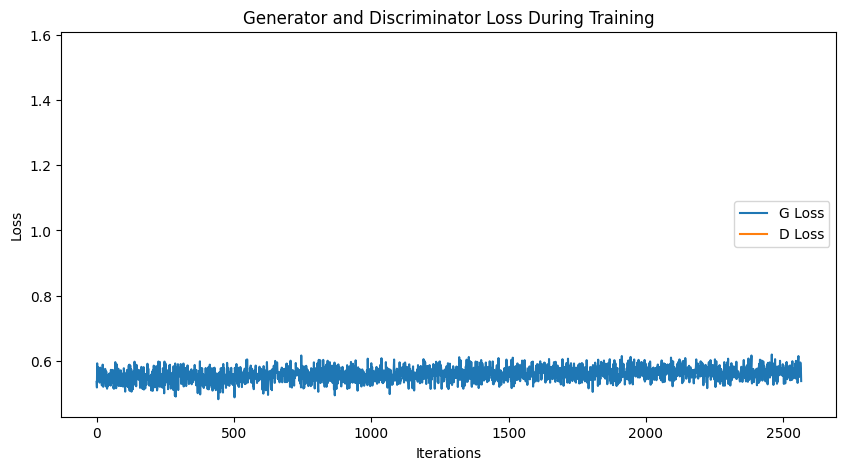

In [26]:
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G Loss")
plt.plot(D_losses, label="D Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()